<h1 style="text-align:center;">Voting Access in California - Geospatial Analysis of the 2024 Presidential Election</h1>

This analysis explores geographic access to voting locations across California counties using spatial data. The goal is to quantify differences in access between counties and evaluate potential disparities in voting access.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind
print(gpd.__version__)

1.1.3


# Import Voter and Map Data

In [2]:
vote_df = pd.read_parquet('data/california_voter_data_by_county_2024.parquet')
vote_df.head()

,county,population,counts_democrat,percent_democrat,counts_republican,percent_republican,counts_other,percent_other,number_of_precincts,eligible_to_register,registered_voters,precinct_voters,vote_by_mail_voters,total_voters,percent_of_vote_by_mail_voters,precent_turnout_registered,precent_turnout_eligible
0,Alameda,1636624,499551,74.6,140789,21.0,29567,4.4,570,1132323,961304,87078,595991,683069,87.25,71.06,60.32
1,Alpine,1086,479,64.9,243,32.9,16,2.2,5,993,954,0,749,749,100.00,78.51,75.43
2,Amador,41974,7783,34.7,14018,62.6,602,2.7,47,28571,26488,2297,20465,22762,89.91,85.93,79.67
3,Butte,208586,44228,46.8,47179,49.9,3149,3.2,132,169890,125088,4014,92092,96106,95.82,76.83,56.57
4,Calaveras,46496,9181,34.7,16625,62.8,674,2.6,25,36435,33059,4567,22318,26885,83.01,81.32,73.79


In [3]:
# Import California county data from U.S. Census 
counties = gpd.read_file("data/tl_2024_us_county/tl_2024_us_county.shp")

# Filter for California  (STATEFP = '06')
counties = counties[counties["STATEFP"] == "06"]

counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
8,06,091,00277310,06091,0500000US06091,Sierra,Sierra County,06,H1,G4020,None,None,None,A,2468694578,23299110,+39.5769252,-120.5219926,"POLYGON ((-120.55587 39.50874, -120.55614 39.5..."
324,06,067,00277298,06067,0500000US06067,Sacramento,Sacramento County,06,H1,G4020,472,40900,None,A,2500063005,75323439,+38.4501363,-121.3443291,"POLYGON ((-121.43991 38.25553, -121.44002 38.2..."
328,06,083,00277306,06083,0500000US06083,Santa Barbara,Santa Barbara County,06,H1,G4020,None,42200,None,A,7080874935,2729198796,+34.5366774,-120.0383645,"MULTIPOLYGON (((-120.58226 34.10752, -120.5790..."
345,06,009,01675885,06009,0500000US06009,Calaveras,Calaveras County,06,H1,G4020,None,None,None,A,2641829625,43797225,+38.1910682,-120.5541065,"POLYGON ((-120.6318 38.34603, -120.63066 38.34..."
393,06,111,00277320,06111,0500000US06111,Ventura,Ventura County,06,H1,G4020,348,37100,None,A,4767597024,947364179,+34.3587477,-119.1331453,"MULTIPOLYGON (((-119.63607 33.28071, -119.6348..."


In [4]:
# Merge map data with voter data 
ca_vote_map = counties.merge(
    vote_df,
    left_on="NAME",
    right_on="county",
    how="left"
)

print(len(ca_vote_map))
print(ca_vote_map["county"].isna().sum())

58
0


In [5]:
# Match coordinate systems
counties = counties.to_crs("EPSG:3310")
counties["county"] = counties["NAME"].str.strip()

In [6]:
print(ca_vote_map.head())

  STATEFP COUNTYFP  COUNTYNS  GEOID         GEOIDFQ           NAME  \
0      06      091  00277310  06091  0500000US06091         Sierra   
1      06      067  00277298  06067  0500000US06067     Sacramento   
2      06      083  00277306  06083  0500000US06083  Santa Barbara   
3      06      009  01675885  06009  0500000US06009      Calaveras   
4      06      111  00277320  06111  0500000US06111        Ventura   

               NAMELSAD LSAD CLASSFP  MTFCC  ... percent_other  \
0         Sierra County   06      H1  G4020  ...           2.7   
1     Sacramento County   06      H1  G4020  ...           3.6   
2  Santa Barbara County   06      H1  G4020  ...           3.1   
3      Calaveras County   06      H1  G4020  ...           2.6   
4        Ventura County   06      H1  G4020  ...           3.0   

  number_of_precincts eligible_to_register registered_voters  precinct_voters  \
0                  19                 2612              2228                0   
1                 68

In [7]:
# Calculate partisan lean by county
ca_vote_map["dem_share"] = ca_vote_map["counts_democrat"]/ca_vote_map["total_voters"]
ca_vote_map["rep_share"] = ca_vote_map["counts_republican"]/ca_vote_map["total_voters"]

# Code for heatmap so (+) = democratic leaning and (-) = republican leaning
ca_vote_map["partisan_lean"] = ca_vote_map["dem_share"] - ca_vote_map["rep_share"]

In [8]:
# Calculate population density
ca_vote_map = ca_vote_map.to_crs("EPSG:3310")
ca_vote_map["area_sq_km"] = ca_vote_map.geometry.area / 1e6
ca_vote_map["population_density"] = (
    ca_vote_map["population"] / ca_vote_map["area_sq_km"]
)

In [9]:
# https://pmc.ncbi.nlm.nih.gov/articles/PMC12081601/
# Calculate precinct density
ca_vote_map["area_sq_km"] = ca_vote_map.geometry.area / 1e6
ca_vote_map["precinct_density"] = (
    ca_vote_map["number_of_precincts"] / ca_vote_map["area_sq_km"]
)

In [10]:
# https://romickinoakley.wordpress.com/2024/02/23/nine-california-counties-make-top-10-list-for-ag-sales-in-the-u-s/
top_ag_counties = ['Fresno', 'Tulare', 'Monterey', 'Kern', 'Merced', 'Imperial', 'San Joaquin', 'Stanislaus', 'Santa Barbara', 'Kings']

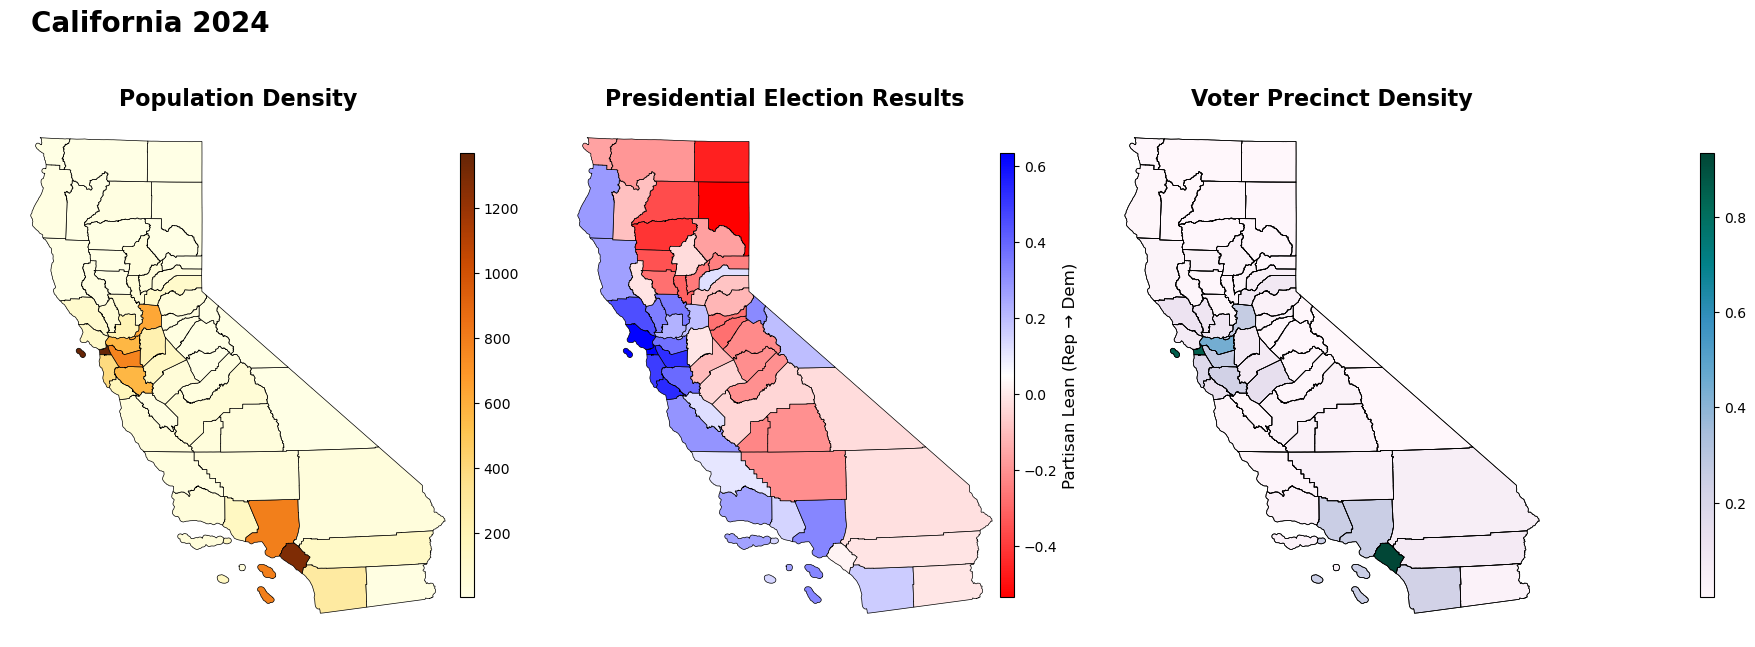

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20,12))

#------------------------Population Plot--------------------------
cax_pop = fig.add_axes([0.35, 0.31, 0.007, 0.37])

ca_vote_map.plot(
    column="population_density",
    cmap="YlOrBr",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=axes[0],
    cax=cax_pop
)

axes[0].set_title(
    "Population Density",
    fontweight='bold',
    fontsize=16
)
axes[0].axis("off")
# Colorbar label
#cax_pop.set_ylabel("Population (Low → High)", fontsize=12)


#----------------Voting Results by County Plot---------------------

cax_party = fig.add_axes([0.62, 0.31, 0.007, 0.37])

ca_vote_map.plot(
    column="partisan_lean",
    cmap="bwr_r",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    cax=cax_party,
    ax=axes[1]
)

axes[1].set_title(
    "Presidential Election Results",
    fontweight='bold',
    fontsize=16
)
axes[1].axis("off")
# Colorbar label
cax_party.set_ylabel("Partisan Lean (Rep → Dem)", fontsize=12)

#------------------- Voting Locations Plot-----------------------

# Add county boundries
counties.boundary.plot(ax=axes[2], linewidth=0.5, color="black")

cax_precincts = fig.add_axes([0.97, 0.31, 0.007, 0.37])

ca_vote_map.plot(
    column="precinct_density",
    cmap="PuBuGn",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=axes[2],
    cax=cax_precincts
)

axes[2].set_title(
    "Voter Precinct Density",
    fontweight='bold',
    fontsize=16
)
axes[2].axis("off")

fig.suptitle("California 2024", fontweight='bold', fontsize=20, y=0.8, x=0.195)
# save option
#plt.savefig('results/california_county_maps_election_results_voting_locations_population_2024.png')
plt.show()